<a href="https://colab.research.google.com/github/Loyse7/CNN_SOIL_CLASSIFICATION/blob/main/CNN_EuroSAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN para Classificação de Imagens de Satélite — EuroSAT

Implementação de uma Rede Neural Convolucional (CNN) para classificação de **cobertura do solo**
a partir de imagens do satélite **Sentinel-2 (ESA)**.

**Dataset:** EuroSAT RGB
- **27.000 imagens** coloridas de 64×64 pixels
- **10 classes** de uso e cobertura do solo
- Coletadas em mais de 34 países europeus

**Referência:** Helber et al., *EuroSAT: A Novel Dataset and Deep Learning Benchmark
for Land Use and Land Cover Classification*, IEEE JSTARS, 2019.

### Métricas implementadas
- Acurácia, Precisão macro, Recall macro e F1-score macro
- Análise das classes mais confundidas
- Curvas de perda e acurácia durante o treinamento
- Matriz de confusão completa (10×10)
- Visualização de mapas de características


In [ ]:
!pip install datasets Pillow -q

from datasets import load_dataset
from torch.utils.data import Dataset
from PIL import Image

class EuroSATDataset(Dataset):
    def __init__(self, split='train', transform=None):
        self.dataset = load_dataset(
            "blanchon/EuroSAT_RGB",
            split=split
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        image = item["image"]      # PIL image
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

print("Dataset carregado diretamente do TFDS.")

Dataset carregado diretamente do TFDS.


In [ ]:
# Importações essenciais do PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# TorchVision para datasets e transformações de imagem
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Reprodutibilidade
SEMENTE = 42
torch.manual_seed(SEMENTE)
np.random.seed(SEMENTE)

# Configuração de dispositivo: usa GPU se disponível, senão CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')   # Apple Silicon (M1, M2...)
else:
    device = torch.device('cpu')

print(f"Dispositivo configurado: {device}")
print(f"Versão do PyTorch: {torch.__version__}")


Dispositivo configurado: cuda
Versão do PyTorch: 2.11.0+cu128


In [ ]:
print(tfds)
print(type(tfds))
print(getattr(tfds, "__file__", "sem arquivo"))

<module 'tensorflow_datasets' from '/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py'>
<class 'module'>
/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py


In [ ]:
print(dir(tfds))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'annotations', 'audio', 'd4rl', 'datasets', 'graphs', 'image', 'image_classification', 'logging', 'nearest_neighbors', 'object_detection', 'question_answering', 'ranking', 'recommendation', 'rl_unplugged', 'robomimic', 'robotics', 'structured', 'summarization', 'text', 'text_simplification', 'time_series', 'translate', 'video', 'vision_language']


import glob

# pasta_dataset foi definida na célula de download
print(f"Usando dataset em: {pasta_dataset}")

# Carrega sem transformações para análise exploratória
dataset_completo_raw = torchvision.datasets.ImageFolder(
    root=pasta_dataset, transform=transforms.ToTensor()
)

nomes_classes = dataset_completo_raw.classes
num_classes   = len(nomes_classes)

print(f"Total de imagens  : {len(dataset_completo_raw)}")
print(f"Número de classes : {num_classes}")
print(f"Classes           : {nomes_classes}")

# Distribuição por classe
contagem_por_classe = {}
for _, label in dataset_completo_raw.samples:
    nome = nomes_classes[label]
    contagem_por_classe[nome] = contagem_por_classe.get(nome, 0) + 1

df_dist = pd.DataFrame(list(contagem_por_classe.items()),
                        columns=['Classe', 'Amostras']).sort_values('Amostras', ascending=False)
print("\nDistribuição por classe:")
print(df_dist.to_string(index=False))

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(12, 4))
cores_dist = ['#2ca02c' if v == df_dist['Amostras'].max()
              else '#d62728' if v == df_dist['Amostras'].min()
              else '#1f77b4' for v in df_dist['Amostras']]
ax.bar(df_dist['Classe'], df_dist['Amostras'], color=cores_dist)
ax.set_title('Distribuição de Amostras por Classe — EuroSAT', fontsize=13)
ax.set_xlabel('Classe')
ax.set_ylabel('Número de Imagens')
ax.set_xticklabels(df_dist['Classe'], rotation=30, ha='right')
ax.axhline(df_dist['Amostras'].mean(), color='orange', linestyle='--',
           label=f'Média ({df_dist["Amostras"].mean():.0f})')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Total de imagens  : 16200
Número de classes : 10
Classes           : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Distribuição por classe:
              Classe  Amostras
         Residential      1863
             SeaLake      1827
HerbaceousVegetation      1799
          AnnualCrop      1791
              Forest      1787
             Highway      1505
          Industrial      1492
       PermanentCrop      1481
               River      1460
             Pasture      1195


/tmp/ipykernel_5013/3879479448.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_dist['Classe'], rotation=30, ha='right')


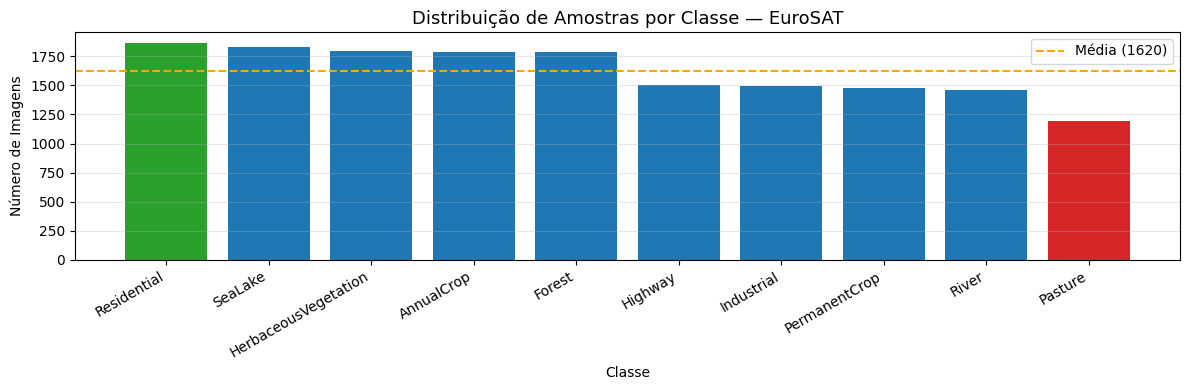

In [ ]:
import tensorflow_datasets as tfds

# Carrega o dataset sem transformações para análise exploratória
dataset_completo_raw = EuroSATDataset(
    split='train',
    transform=transforms.ToTensor()
)

nomes_classes = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

num_classes = len(nomes_classes)

print(f"Total de imagens  : {len(dataset_completo_raw)}")
print(f"Número de classes : {num_classes}")
print(f"Classes           : {nomes_classes}")

# Distribuição por classe
contagem_por_classe = {}
for _, label in dataset_completo_raw:
    nome = nomes_classes[label]
    contagem_por_classe[nome] = contagem_por_classe.get(nome, 0) + 1

df_dist = pd.DataFrame(list(contagem_por_classe.items()),
                        columns=['Classe', 'Amostras']).sort_values('Amostras', ascending=False)
print("\nDistribuição por classe:")
print(df_dist.to_string(index=False))

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(12, 4))
cores_dist = ['#2ca02c' if v == df_dist['Amostras'].max()
              else '#d62728' if v == df_dist['Amostras'].min()
              else '#1f77b4' for v in df_dist['Amostras']]
ax.bar(df_dist['Classe'], df_dist['Amostras'], color=cores_dist)
ax.set_title('Distribuição de Amostras por Classe — EuroSAT', fontsize=13)
ax.set_xlabel('Classe')
ax.set_ylabel('Número de Imagens')
ax.set_xticklabels(df_dist['Classe'], rotation=30, ha='right')
ax.axhline(df_dist['Amostras'].mean(), color='orange', linestyle='--',
           label=f'Média ({df_dist["Amostras"].mean():.0f})')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

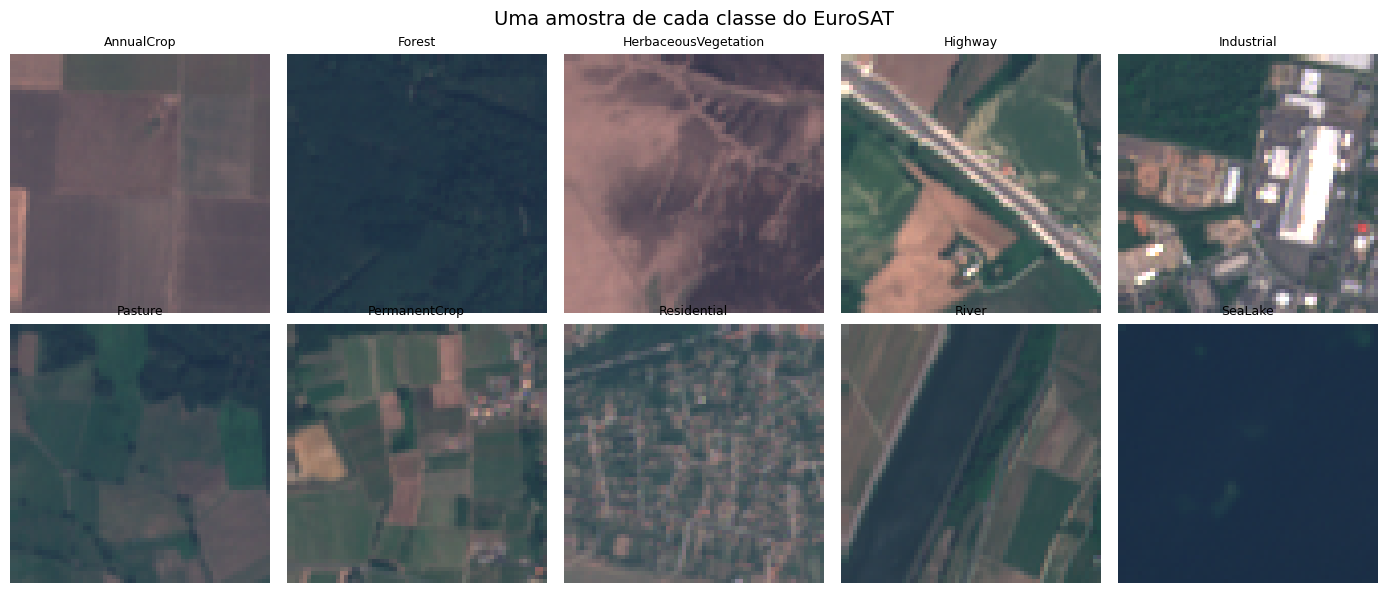

In [ ]:
# Exibe uma amostra de cada classe para inspeção visual
fig, eixos = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Uma amostra de cada classe do EuroSAT", fontsize=14)

# Índice da primeira ocorrência de cada classe
indices_por_classe = {label: None for label in range(num_classes)}
for idx, (_, label) in enumerate(dataset_completo_raw):
    if indices_por_classe[label] is None:
        indices_por_classe[label] = idx
    if all(v is not None for v in indices_por_classe.values()):
        break

for classe_id, ax in enumerate(eixos.flat):
    imagem, _ = dataset_completo_raw[indices_por_classe[classe_id]]
    ax.imshow(imagem.permute(1, 2, 0).numpy())
    ax.set_title(nomes_classes[classe_id], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


## Pré-processamento e Divisão dos Dados

In [ ]:
# Média e desvio padrão do EuroSAT RGB (por canal R, G, B)
# Valores calculados a partir do dataset completo
MEDIA_EUROSAT  = (0.3444, 0.3803, 0.4078)
DESVIO_EUROSAT = (0.2026, 0.1366, 0.1148)

# Transformações de treino: inclui data augmentation para generalização
transformacao_treino = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # Espelhamento horizontal aleatório
    transforms.RandomVerticalFlip(),             # Espelhamento vertical (válido p/ satélite)
    transforms.RandomRotation(degrees=90),       # Rotação aleatória (imagens de satélite
                                                 # não têm orientação preferencial)
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.1),      # Variações de iluminação
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_EUROSAT, DESVIO_EUROSAT)
])

# Transformações de validação/teste: apenas normalização
transformacao_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_EUROSAT, DESVIO_EUROSAT)
])

# Carrega o dataset completo com as transformações de treino
dataset_completo = EuroSATDataset(
    split='train',
    transform=transformacao_treino
)

# Divisão: 70% treino, 15% validação, 15% teste
total     = len(dataset_completo)
n_treino  = int(0.70 * total)
n_val     = int(0.15 * total)
n_teste   = total - n_treino - n_val

gerador = torch.Generator().manual_seed(SEMENTE)
dataset_treino, dataset_val, dataset_teste = random_split(
    dataset_completo, [n_treino, n_val, n_teste], generator=gerador
)

dataset_val.dataset.transform = transformacao_val
dataset_teste.dataset.transform = transformacao_val

# DataLoaders
loader_treino = DataLoader(dataset_treino, batch_size=64, shuffle=True,
                            num_workers=0, pin_memory=True)
loader_val    = DataLoader(dataset_val,    batch_size=128, shuffle=False,
                            num_workers=0, pin_memory=True)
loader_teste  = DataLoader(dataset_teste,  batch_size=128, shuffle=False,
                            num_workers=0, pin_memory=True)

print(f"Total de imagens : {total}")
print(f"Treino           : {len(dataset_treino)} imagens ({len(dataset_treino)/total*100:.0f}%)")
print(f"Validação        : {len(dataset_val)} imagens ({len(dataset_val)/total*100:.0f}%)")
print(f"Teste            : {len(dataset_teste)} imagens ({len(dataset_teste)/total*100:.0f}%)")
print(f"Número de classes: {num_classes}")


Total de imagens : 16200
Treino           : 11340 imagens (70%)
Validação        : 2430 imagens (15%)
Teste            : 2430 imagens (15%)
Número de classes: 10


## Definição do Modelo CNN

In [ ]:
class RedeCNN(nn.Module):
    """
    CNN para classificação de imagens de satélite EuroSAT.

    Adaptada para imagens 64x64 (vs 32x32 do CIFAR):
      - Um bloco convolucional extra para capturar estruturas de maior escala
      - Menos filtros nos primeiros blocos (imagens de satélite têm textura
        mais regular que fotografias naturais)

    Fluxo dos dados:
      Entrada (3, 64, 64)
        → Bloco Conv 1 (32 filtros)  → (32, 32, 32)
        → Bloco Conv 2 (64 filtros)  → (64, 16, 16)
        → Bloco Conv 3 (128 filtros) → (128, 8, 8)
        → Bloco Conv 4 (256 filtros) → (256, 4, 4)
        → Classificador              → 10 classes
    """
    def __init__(self, num_classes: int = 10):
        super(RedeCNN, self).__init__()

        # --- PARTE 1: Extrator de Características ---
        self.convolucoes = nn.Sequential(

            # Bloco 1: 3 canais RGB → 32 mapas de características
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # 64×64 → 32×32
            nn.Dropout2d(0.1),

            # Bloco 2: 32 → 64 mapas
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # 32×32 → 16×16
            nn.Dropout2d(0.2),

            # Bloco 3: 64 → 128 mapas
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # 16×16 → 8×8
            nn.Dropout2d(0.3),

            # Bloco 4: 128 → 256 mapas
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),      # 8×8 → 4×4
            nn.Dropout2d(0.3),
        )

        # --- PARTE 2: Classificador ---
        # Após os blocos: 256 canais × 4×4 = 4096 características
        self.classificador = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, num_classes)   # 10 classes de saída
        )

        self._inicializar_pesos()

    def _inicializar_pesos(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.convolucoes(x)
        x = self.classificador(x)
        return x


# Instancia e envia para o dispositivo
modelo = RedeCNN(num_classes=num_classes).to(device)
print(modelo)
print(f"\nTotal de parâmetros    : {sum(p.numel() for p in modelo.parameters()):,}")
print(f"Parâmetros treináveis  : {sum(p.numel() for p in modelo.parameters() if p.requires_grad):,}")


RedeCNN(
  (convolucoes): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.2, in

## Treinamento

In [ ]:
# ── Perda e Otimizador ────────────────────────────────────────────────────
criterio   = nn.CrossEntropyLoss(label_smoothing=0.1)
otimizador = optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=1e-4)

# Reduz o LR seguindo uma curva cosseno ao longo das épocas
scheduler = optim.lr_scheduler.CosineAnnealingLR(otimizador, T_max=50, eta_min=1e-6)

epocas = 30   # ajuste conforme o tempo disponível

# Histórico de métricas
historico_perda_treino = []
historico_acc_treino   = []
historico_perda_val    = []
historico_acc_val      = []

# Early stopping
paciencia          = 8
melhor_acc_val     = 0.0
contador_paciencia = 0
melhor_estado      = None

print("Iniciando o Treinamento...\n")

for epoca in range(epocas):

    # ── Fase de Treino ──────────────────────────────────────────────────
    modelo.train()
    perda_acumulada = 0.0
    acertos_treino  = 0
    total_treino    = 0

    for imagens, rotulos in tqdm(loader_treino, desc=f"Época {epoca+1:02d}/{epocas}", leave=False):
        imagens, rotulos = imagens.to(device), rotulos.to(device)

        otimizador.zero_grad()
        saidas = modelo(imagens)
        perda  = criterio(saidas, rotulos)
        perda.backward()
        otimizador.step()

        perda_acumulada += perda.item()
        _, previsoes     = torch.max(saidas, 1)
        acertos_treino  += (previsoes == rotulos).sum().item()
        total_treino    += rotulos.size(0)

    media_perda_treino = perda_acumulada / len(loader_treino)
    acc_treino         = acertos_treino / total_treino

    # ── Fase de Validação ────────────────────────────────────────────────
    modelo.eval()
    perda_val_acum = 0.0
    acertos_val    = 0
    total_val      = 0

    with torch.no_grad():
        for imagens, rotulos in loader_val:
            imagens, rotulos = imagens.to(device), rotulos.to(device)
            saidas = modelo(imagens)
            perda_val_acum += criterio(saidas, rotulos).item()
            _, previsoes    = torch.max(saidas, 1)
            acertos_val    += (previsoes == rotulos).sum().item()
            total_val      += rotulos.size(0)

    media_perda_val = perda_val_acum / len(loader_val)
    acc_val         = acertos_val / total_val

    scheduler.step()

    historico_perda_treino.append(media_perda_treino)
    historico_acc_treino.append(acc_treino)
    historico_perda_val.append(media_perda_val)
    historico_acc_val.append(acc_val)

    print(
        f"Época [{epoca+1:02d}/{epocas}] | "        f"Treino — Erro: {media_perda_treino:.4f}, Acc: {acc_treino:.4f} | "        f"Validação — Erro: {media_perda_val:.4f}, Acc: {acc_val:.4f}"
    )

    # Early stopping
    if acc_val > melhor_acc_val:
        melhor_acc_val     = acc_val
        contador_paciencia = 0
        melhor_estado      = {k: v.cpu().clone() for k, v in modelo.state_dict().items()}
    else:
        contador_paciencia += 1
        if contador_paciencia >= paciencia:
            print(f"\nEarly stopping na época {epoca+1}. Melhor acc validação: {melhor_acc_val:.4f}")
            break

# Restaura o melhor modelo
modelo.load_state_dict(melhor_estado)
print(f"\nTreinamento concluído! Melhor acurácia na validação: {melhor_acc_val:.4f}")


Iniciando o Treinamento...



Época 01/30:   0%|          | 0/178 [00:00<?, ?it/s]

Época [01/30] | Treino — Erro: 1.5518, Acc: 0.5289 | Validação — Erro: 1.2403, Acc: 0.6523


Época 02/30:   0%|          | 0/178 [00:00<?, ?it/s]

Época [02/30] | Treino — Erro: 1.2818, Acc: 0.6606 | Validação — Erro: 1.0589, Acc: 0.7646


...

Época [28/30] | Treino — Erro: 0.6605, Acc: 0.9411 | Validação — Erro: 0.6470, Acc: 0.9391


Época 29/30:   0%|          | 0/178 [00:00<?, ?it/s]

Época [29/30] | Treino — Erro: 0.6483, Acc: 0.9459 | Validação — Erro: 0.6102, Acc: 0.9547


Época 30/30:   0%|          | 0/178 [00:00<?, ?it/s]

Época [30/30] | Treino — Erro: 0.6439, Acc: 0.9489 | Validação — Erro: 0.6068, Acc: 0.9568

Treinamento concluído! Melhor acurácia na validação: 0.9568


## Curvas de Aprendizado

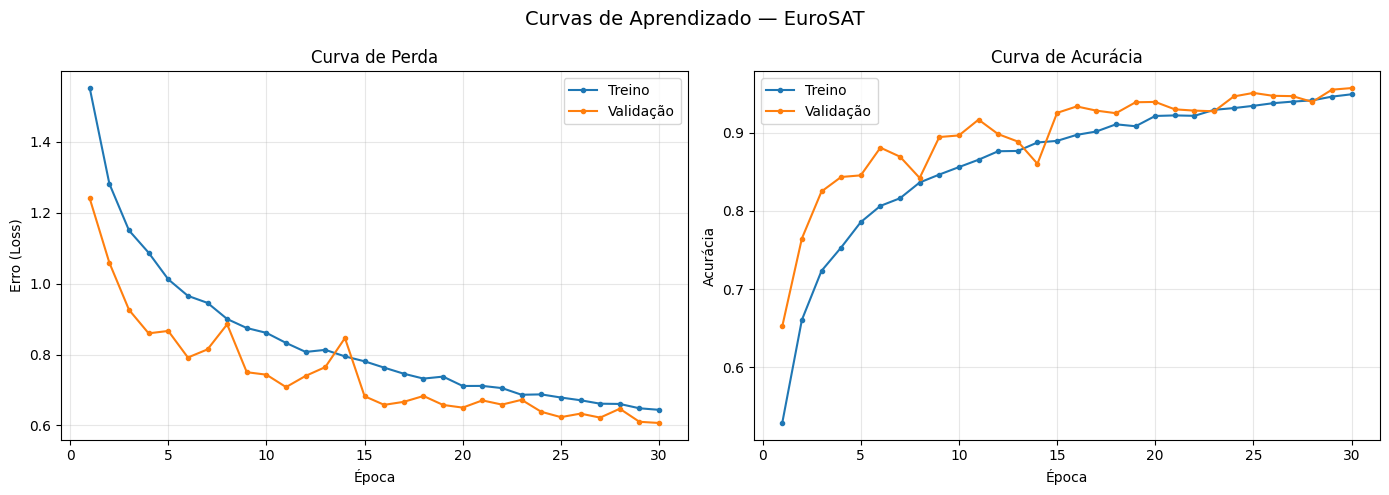

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epocas_exec = range(1, len(historico_perda_treino) + 1)

ax1.plot(epocas_exec, historico_perda_treino, marker='o', markersize=3, label='Treino')
ax1.plot(epocas_exec, historico_perda_val,    marker='o', markersize=3, label='Validação')
ax1.set_xlabel('Época')
ax1.set_ylabel('Erro (Loss)')
ax1.set_title('Curva de Perda')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epocas_exec, historico_acc_treino, marker='o', markersize=3, label='Treino')
ax2.plot(epocas_exec, historico_acc_val,    marker='o', markersize=3, label='Validação')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.set_title('Curva de Acurácia')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizado — EuroSAT', fontsize=14)
plt.tight_layout()
plt.show()


## Avaliação no Conjunto de Teste

In [ ]:
modelo.eval()

todas_previsoes = []
todos_rotulos   = []

with torch.no_grad():
    for imagens, rotulos in loader_teste:
        imagens, rotulos = imagens.to(device), rotulos.to(device)
        saidas = modelo(imagens)
        _, previsoes = torch.max(saidas.data, 1)
        todas_previsoes.extend(previsoes.cpu().numpy())
        todos_rotulos.extend(rotulos.cpu().numpy())

# ── Métricas globais ───────────────────────────────────────────────────────
acuracia = accuracy_score(todos_rotulos, todas_previsoes)
precisao = precision_score(todos_rotulos, todas_previsoes, average='macro', zero_division=0)
recall   = recall_score(todos_rotulos, todas_previsoes, average='macro', zero_division=0)
f1       = f1_score(todos_rotulos, todas_previsoes, average='macro', zero_division=0)

print("=" * 50)
print(f"  Acurácia         : {acuracia * 100:.2f}%")
print(f"  Precisão (macro) : {precisao * 100:.2f}%")
print(f"  Recall (macro)   : {recall * 100:.2f}%")
print(f"  F1-score (macro) : {f1 * 100:.2f}%")
print("=" * 50)


  Acurácia         : 96.30%
  Precisão (macro) : 96.21%
  Recall (macro)   : 96.26%
  F1-score (macro) : 96.20%


In [ ]:
print(classification_report(
    todos_rotulos, todas_previsoes,
    target_names=nomes_classes,
    digits=4,
    zero_division=0
))


                      precision    recall  f1-score   support

          AnnualCrop     0.9670    0.9362    0.9514       282
              Forest     0.9891    0.9927    0.9909       273
HerbaceousVegetation     0.9474    0.9130    0.9299       276
             Highway     0.9665    0.9712    0.9688       208
          Industrial     0.9873    0.9957    0.9915       235
             Pasture     0.9323    0.9728    0.9521       184
       PermanentCrop     0.8760    0.9481    0.9106       231
         Residential     0.9922    0.9922    0.9922       256
               River     0.9735    0.9109    0.9412       202
             SeaLake     0.9894    0.9929    0.9912       283

            accuracy                         0.9630      2430
           macro avg     0.9621    0.9626    0.9620      2430
        weighted avg     0.9637    0.9630    0.9630      2430



## Análise das Classes Mais Confundidas

=== Classes por Acurácia (menor → maior) ===
 classe_id                 nome  total  corretos  acuracia
         8                River    202       184  0.910891
         2 HerbaceousVegetation    276       252  0.913043
         0           AnnualCrop    282       264  0.936170
         6        PermanentCrop    231       219  0.948052
         3              Highway    208       202  0.971154
         5              Pasture    184       179  0.972826
         7          Residential    256       254  0.992188
         1               Forest    273       271  0.992674
         9              SeaLake    283       281  0.992933
         4           Industrial    235       234  0.995745


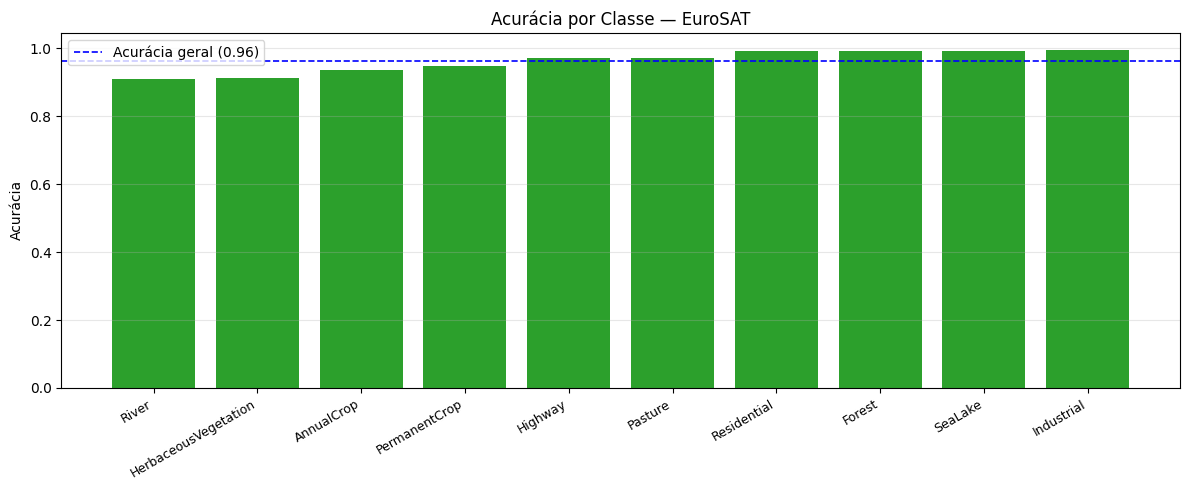

In [ ]:
acuracia_por_classe = []

for classe_id, nome in enumerate(nomes_classes):
    indices  = [i for i, r in enumerate(todos_rotulos) if r == classe_id]
    corretos = sum(1 for i in indices if todas_previsoes[i] == classe_id)
    acuracia_por_classe.append({
        'classe_id': classe_id,
        'nome': nome,
        'total': len(indices),
        'corretos': corretos,
        'acuracia': corretos / len(indices) if indices else 0
    })

df_classes = pd.DataFrame(acuracia_por_classe).sort_values('acuracia')

print("=== Classes por Acurácia (menor → maior) ===")
print(df_classes.to_string(index=False))

# Gráfico de barras por classe
fig, ax = plt.subplots(figsize=(12, 5))
cores = ['#d62728' if a < 0.7 else '#ff7f0e' if a < 0.85 else '#2ca02c'
         for a in df_classes['acuracia']]
ax.bar(range(len(df_classes)), df_classes['acuracia'], color=cores)
ax.set_xticks(range(len(df_classes)))
ax.set_xticklabels(df_classes['nome'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia por Classe — EuroSAT')
ax.axhline(acuracia, color='blue', linestyle='--', linewidth=1.2,
           label=f'Acurácia geral ({acuracia:.2f})')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print("=== Análise detalhada das confusões ===\n")

for _, row in df_classes.head(5).iterrows():
    classe_id = int(row['classe_id'])
    indices   = [i for i, r in enumerate(todos_rotulos) if r == classe_id]
    erradas   = [todas_previsoes[i] for i in indices if todas_previsoes[i] != classe_id]

    if not erradas:
        continue

    contagem = {}
    for p in erradas:
        contagem[nomes_classes[p]] = contagem.get(nomes_classes[p], 0) + 1
    top = sorted(contagem.items(), key=lambda x: -x[1])[:5]

    print(f"Classe '{row['nome']}' (acc={row['acuracia']:.2f}) confundida com:")
    for nome_conf, qtd in top:
        print(f"  → '{nome_conf}': {qtd} vez(es)")
    print()


=== Análise detalhada das confusões ===

Classe 'River' (acc=0.91) confundida com:
  → 'Pasture': 5 vez(es)
  → 'HerbaceousVegetation': 4 vez(es)
  → 'PermanentCrop': 4 vez(es)
  → 'AnnualCrop': 2 vez(es)
  → 'Highway': 2 vez(es)

Classe 'HerbaceousVegetation' (acc=0.91) confundida com:
  → 'PermanentCrop': 16 vez(es)
  → 'Pasture': 3 vez(es)
  → 'Highway': 1 vez(es)
  → 'Forest': 1 vez(es)
  → 'Residential': 1 vez(es)

Classe 'AnnualCrop' (acc=0.94) confundida com:
  → 'PermanentCrop': 9 vez(es)
  → 'Pasture': 4 vez(es)
  → 'SeaLake': 3 vez(es)
  → 'River': 2 vez(es)

Classe 'PermanentCrop' (acc=0.95) confundida com:
  → 'HerbaceousVegetation': 6 vez(es)
  → 'AnnualCrop': 4 vez(es)
  → 'Highway': 2 vez(es)

Classe 'Highway' (acc=0.97) confundida com:
  → 'River': 2 vez(es)
  → 'Forest': 1 vez(es)
  → 'Industrial': 1 vez(es)
  → 'Residential': 1 vez(es)
  → 'PermanentCrop': 1 vez(es)



## Matriz de Confusão (10 Classes)

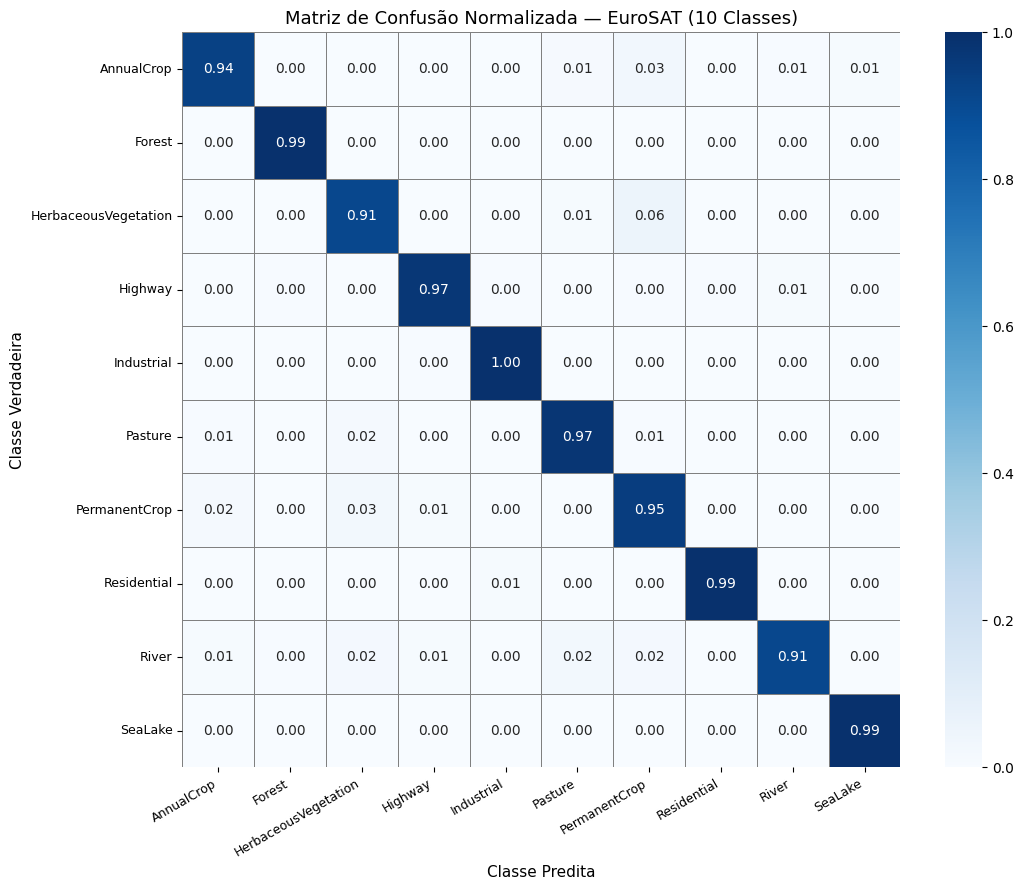

In [ ]:
cm = confusion_matrix(todos_rotulos, todas_previsoes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=nomes_classes,
    yticklabels=nomes_classes,
    linewidths=0.5, linecolor='gray',
    vmin=0, vmax=1
)
ax.set_title('Matriz de Confusão Normalizada — EuroSAT (10 Classes)', fontsize=13)
ax.set_xlabel('Classe Predita', fontsize=11)
ax.set_ylabel('Classe Verdadeira', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


## Exemplos de Acertos e Erros

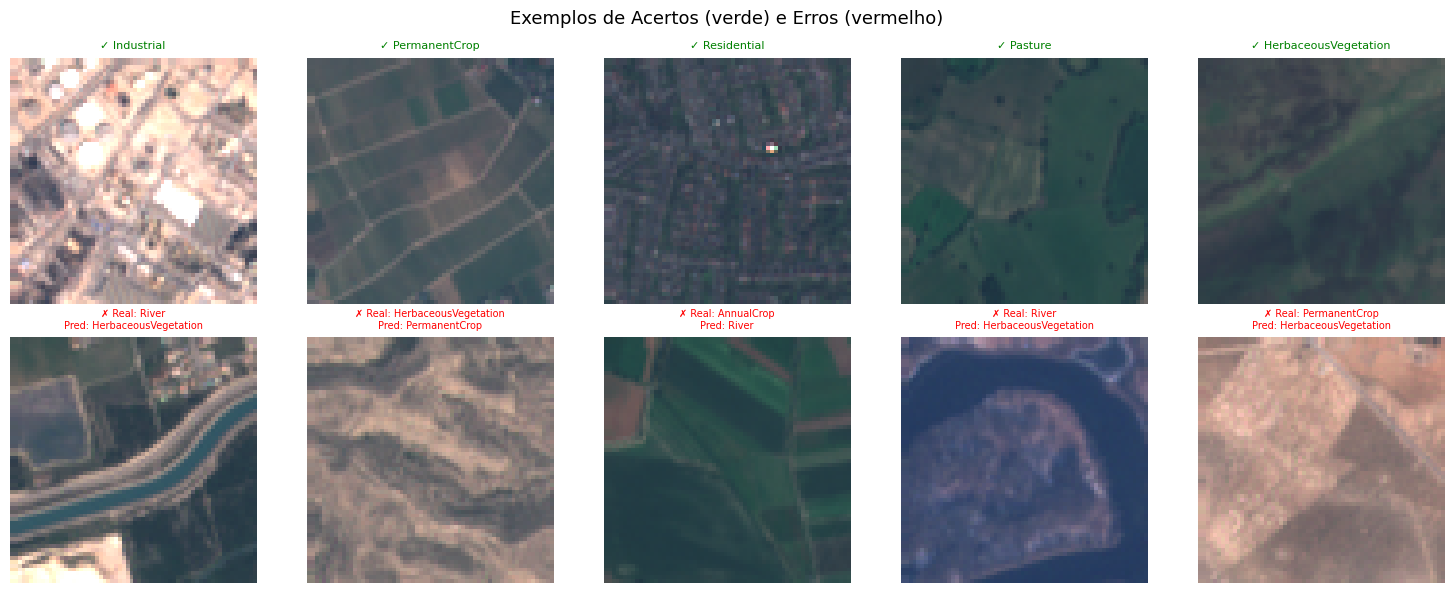

In [ ]:
# Dataset de teste sem augmentation para visualização
dataset_teste_visual = EuroSATDataset(
    split='train',
    transform=transforms.ToTensor()
)
# Filtra apenas os índices do split de teste
indices_teste = dataset_teste.indices

acertos_idx = []
erros_idx   = []

for i, idx_global in enumerate(indices_teste):
    pred  = todas_previsoes[i]
    real  = todos_rotulos[i]
    if pred == real and len(acertos_idx) < 5:
        acertos_idx.append((idx_global, real, pred))
    elif pred != real and len(erros_idx) < 5:
        erros_idx.append((idx_global, real, pred))
    if len(acertos_idx) == 5 and len(erros_idx) == 5:
        break

fig, eixos = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Exemplos de Acertos (verde) e Erros (vermelho)', fontsize=13)

for col, (idx, real, pred) in enumerate(acertos_idx):
    imagem, _ = dataset_teste_visual[idx]
    eixos[0, col].imshow(imagem.permute(1, 2, 0).numpy())
    eixos[0, col].set_title(f"✓ {nomes_classes[real]}", fontsize=8, color='green')
    eixos[0, col].axis('off')

for col, (idx, real, pred) in enumerate(erros_idx):
    imagem, _ = dataset_teste_visual[idx]
    eixos[1, col].imshow(imagem.permute(1, 2, 0).numpy())
    eixos[1, col].set_title(
        f"✗ Real: {nomes_classes[real]}\nPred: {nomes_classes[pred]}",
        fontsize=7, color='red'
    )
    eixos[1, col].axis('off')

plt.tight_layout()
plt.show()


## Salvar e Carregar o Modelo

In [ ]:
caminho_modelo = 'modelo_eurosat_cnn.pth'
torch.save(modelo.state_dict(), caminho_modelo)
print(f"Pesos salvos em: {caminho_modelo}")

# Para carregar:
modelo_carregado = RedeCNN(num_classes=num_classes).to(device)
modelo_carregado.load_state_dict(torch.load(caminho_modelo, map_location=device))
modelo_carregado.eval()
print("Modelo carregado com sucesso!")


Pesos salvos em: modelo_eurosat_cnn.pth
Modelo carregado com sucesso!


## Predição Individual

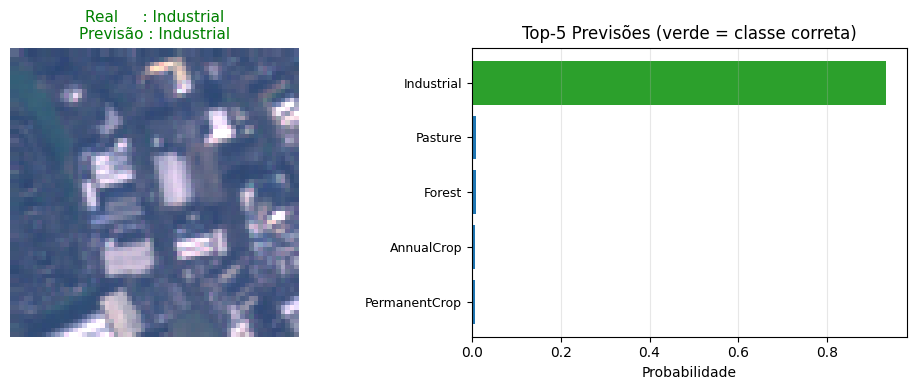

In [ ]:
indice_exemplo   = indices_teste[10]
imagem_teste, rotulo_verdadeiro = dataset_teste_visual[indice_exemplo]

imagem_norm = transformacao_val(
    torchvision.transforms.functional.to_pil_image(imagem_teste)
).unsqueeze(0).to(device)

with torch.no_grad():
    saida = modelo_carregado(imagem_norm)
    probabilidades = torch.softmax(saida, dim=1).squeeze(0).cpu().numpy()
    classe_prevista = int(probabilidades.argmax())

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(imagem_teste.permute(1, 2, 0).numpy())
cor_titulo = 'green' if classe_prevista == rotulo_verdadeiro else 'red'
ax1.set_title(
    f"Real     : {nomes_classes[rotulo_verdadeiro]}\n"    f"Previsão : {nomes_classes[classe_prevista]}",
    fontsize=11, color=cor_titulo
)
ax1.axis('off')

top5_idx  = probabilidades.argsort()[-5:][::-1]
top5_prob = probabilidades[top5_idx]
top5_nome = [nomes_classes[i] for i in top5_idx]
cores_bar = ['#2ca02c' if i == rotulo_verdadeiro else '#1f77b4' for i in top5_idx]

ax2.barh(range(5), top5_prob[::-1], color=cores_bar[::-1])
ax2.set_yticks(range(5))
ax2.set_yticklabels(top5_nome[::-1], fontsize=9)
ax2.set_xlabel('Probabilidade')
ax2.set_title('Top-5 Previsões (verde = classe correta)')
ax2.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Visualização dos Mapas de Características

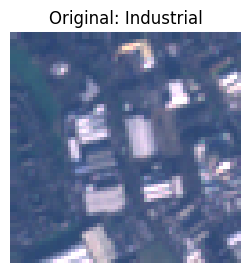

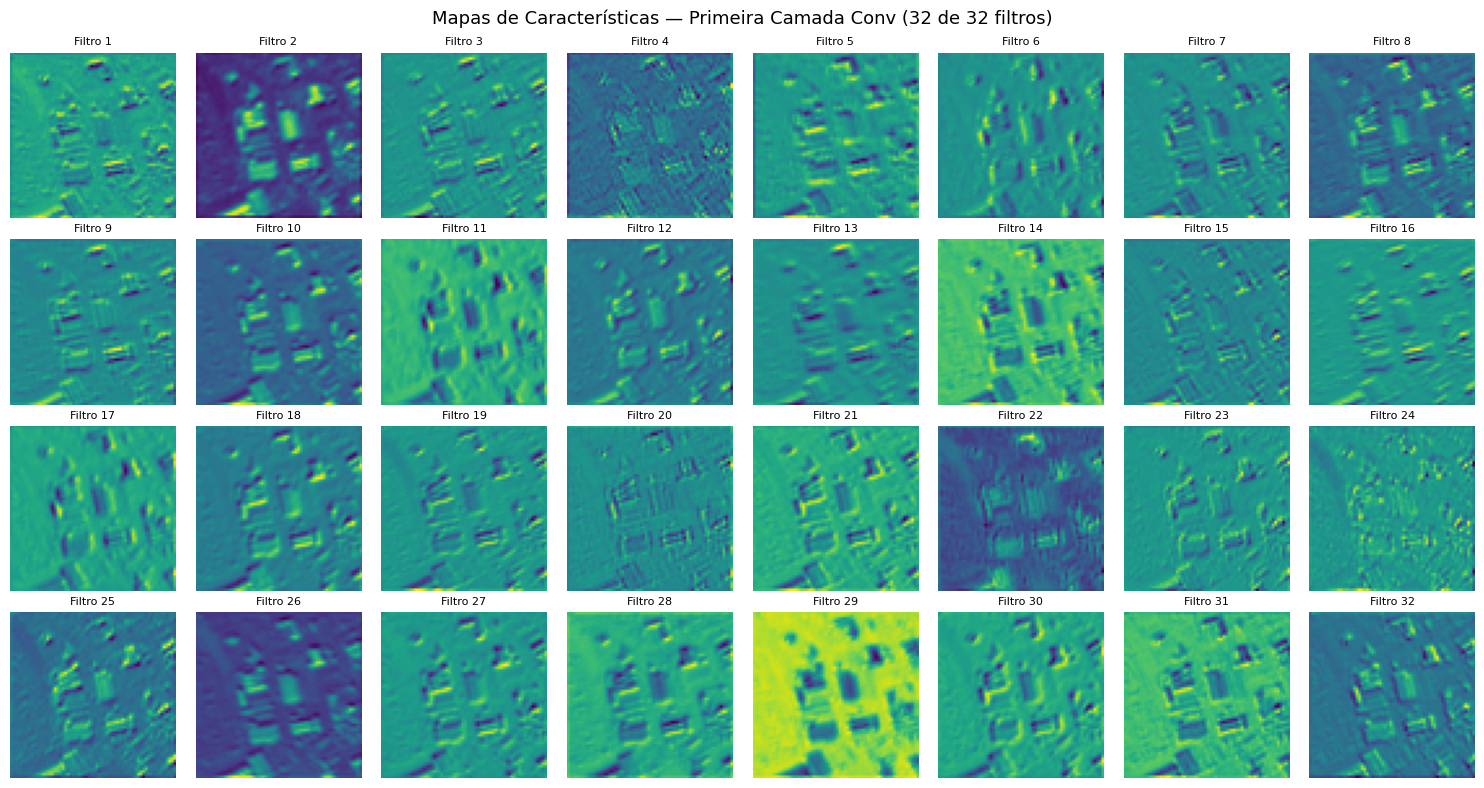

In [ ]:
camada_conv1 = modelo_carregado.convolucoes[0]
imagem_entrada = imagem_norm  # reutiliza a imagem da célula anterior

with torch.no_grad():
    mapas_feat = camada_conv1(imagem_entrada)

mapas = mapas_feat.squeeze(0).cpu().numpy()

# Imagem original
plt.figure(figsize=(3, 3))
plt.imshow(imagem_teste.permute(1, 2, 0).numpy())
plt.title(f"Original: {nomes_classes[rotulo_verdadeiro]}")
plt.axis('off')
plt.show()

# Primeiros 32 dos mapas de características
fig, eixos = plt.subplots(4, 8, figsize=(15, 8))
fig.suptitle("Mapas de Características — Primeira Camada Conv (32 de 32 filtros)", fontsize=13)

for i, ax in enumerate(eixos.flat):
    ax.imshow(mapas[i], cmap='viridis')
    ax.set_title(f"Filtro {i+1}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()
